In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

import seaborn as sns; sns.set_theme()

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.dummy import DummyRegressor

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score, cross_validate


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.set_printoptions(precision=3, suppress=True)

### Load Data, Dataförståelse & EDA

Datasetet innehåller 9 kolumner med 8 feature (longitude, latitude, housing_median_age, total_rooms, total_bedrooms, population, households, median_income) samt target median_house_value. 
Dataset innehåller 20 640 rader och 10 kolumner. Det finns både flera numeriska och en kategoriska variabler.  Kategorisk variabel ocean_proximity visar avstånd till kusten.
I den inledande dataanalysen såg jag ett tydligt positivt samband mellan medianinkomst och medianhusvärde
Fördelningen av husvärden är rätt skev, vilket indikerar några högvärdiga extremvärden.

In [21]:
df = pd.read_csv("housing.csv")

df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### Missing value
Den enda kolumnen total_bedrooms har 207 saknade värden som jag har fyllt i med medianen.

In [22]:
print(df.isna().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [23]:
df["total_bedrooms"].isnull().sum()
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

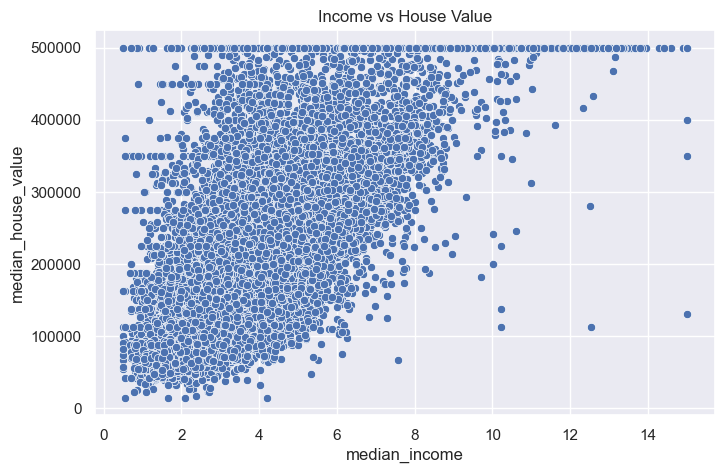

In [24]:
# Figure 1: Income vs House Value
plt.figure(figsize=(8, 5))
sns.scatterplot(x="median_income", y="median_house_value", data=df)
plt.title("Income vs House Value")
plt.show()


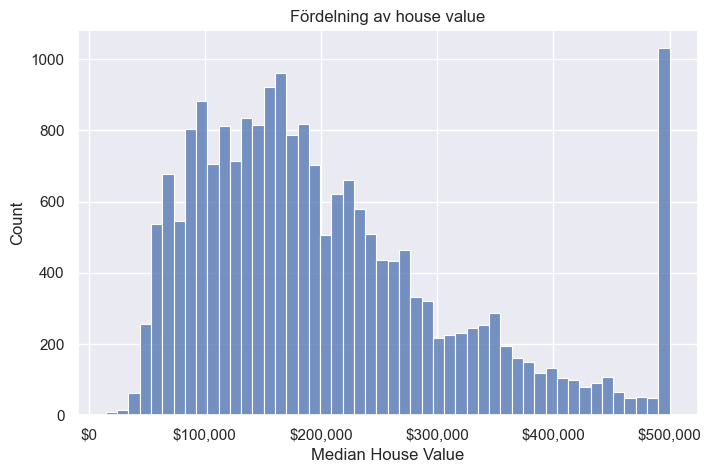

In [25]:
# Figure 2: Fördelning av house value
plt.figure(figsize=(8, 5))
sns.histplot(df["median_house_value"], bins=50)
plt.title("Fördelning av house value")
plt.xlabel("Median House Value")
plt.ylabel("Count")
plt.gca().xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))    
plt.show()



### Data Split & Preprocessing
Data delades upp med 80 procent för träna modellen och 20 procent för tästa. Förbehandling implementerades med hjälp av en pipeline för att undvika dataläckage.
I den numeriska pipelinen har jag använt SimpleImputer och StandardScaler funktionen.
För den kategoriska pipelinen har jag använt OneHotEncoder funktionen.

In [26]:
target_column_name = "median_house_value"
feature_column_names = [col for col in df.columns if col != target_column_name]

X = df[feature_column_names]
y = df[target_column_name]



# Feature engineering
def add_features(X):
    X = X.copy()
    X["rooms_per_household"] = X["total_rooms"] / X["households"]
    X["bedrooms_per_room"] = X["total_bedrooms"] / X["total_rooms"]
    X["population_per_household"] = X["population"] / X["households"]
    return X

feature_engineering = FunctionTransformer(add_features)

X = add_features(X)

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["str"]).columns.tolist()

print("Nummeriska kolumner:", numeric_features)
print("Kategoriska kolumner:", categorical_features)
print("\n" )

# Kategorisk sammanfattning
print("Kategorisk sammanfattning:")
for col in categorical_features:
    print(f"{col}:")
    print(df[col].value_counts())


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("\n" )
print("Full Data shape:", X.shape)
print("Train Data shape:", X_train.shape)
print("Test Data shape:", X_test.shape)
print("\n" )

print("X_Train Data Statistical description" )
display(X_train.describe().T)
print("y_Train Data Statistical description" )
y_train.describe()

Nummeriska kolumner: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']
Kategoriska kolumner: ['ocean_proximity']


Kategorisk sammanfattning:
ocean_proximity:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


Full Data shape: (20640, 12)
Train Data shape: (16512, 12)
Test Data shape: (4128, 12)


X_Train Data Statistical description


,count,mean,std,min,25%,50%,75%,max
longitude,16512.0,-119.582290,2.005654,-124.350000,-121.810000,-118.510000,-118.010000,-114.310000
latitude,16512.0,35.643149,2.136665,32.550000,33.930000,34.260000,37.720000,41.950000
housing_median_age,16512.0,28.608285,12.602499,1.000000,18.000000,29.000000,37.000000,52.000000
total_rooms,16512.0,2642.004784,2174.646744,2.000000,1454.000000,2129.000000,3160.000000,39320.000000
total_bedrooms,16512.0,538.496851,419.007096,1.000000,296.750000,437.000000,647.000000,6445.000000
population,16512.0,1426.453004,1137.056380,3.000000,789.000000,1167.000000,1726.000000,35682.000000
households,16512.0,499.986919,380.967964,1.000000,280.000000,410.000000,606.000000,6082.000000
median_income,16512.0,3.880754,1.904294,0.499900,2.566700,3.545800,4.773175,15.000100
rooms_per_household,16512.0,5.435235,2.387375,0.888889,4.452055,5.235874,6.061037,141.909091
bedrooms_per_room,16512.0,0.212858,0.057995,0.100000,0.175178,0.202808,0.239501,1.000000


y_Train Data Statistical description


count     16512.000000
mean     207194.693738
std      115622.626448
min       14999.000000
25%      119800.000000
50%      179850.000000
75%      265125.000000
max      500001.000000
Name: median_house_value, dtype: float64

Heatmappen visar på korrelation mellan flera variabler. Korrelationsanalysen visar att medianinkomsten är den starkaste prediktorn för husvärde (0,69), medan de flesta andra variabler har svaga individuella samband. Höga korrelationer mellan variabler som rum, sovrum och hushåll stöder användningen av feature engineering och trädbaserade modeller som Random Forest.

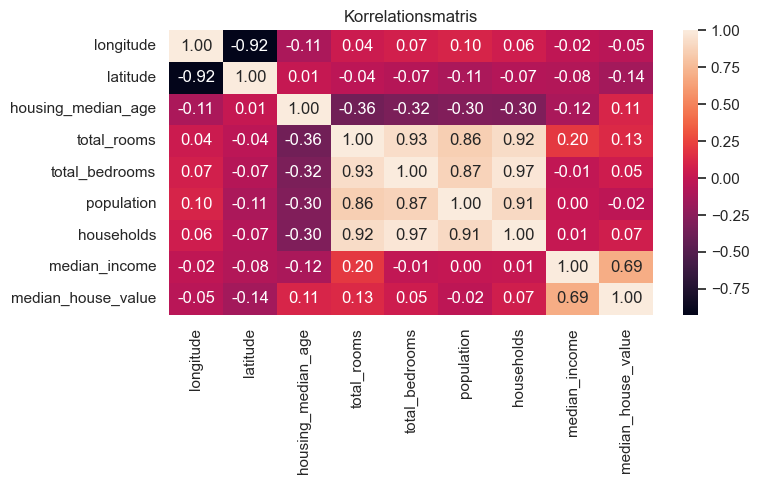

In [27]:
correlation_matrix = df.corr(numeric_only=True) 

fig, ax = plt.subplots(figsize=(8,5))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", ax=ax)
ax.set_title("Korrelationsmatris")
plt.tight_layout()
plt.show()

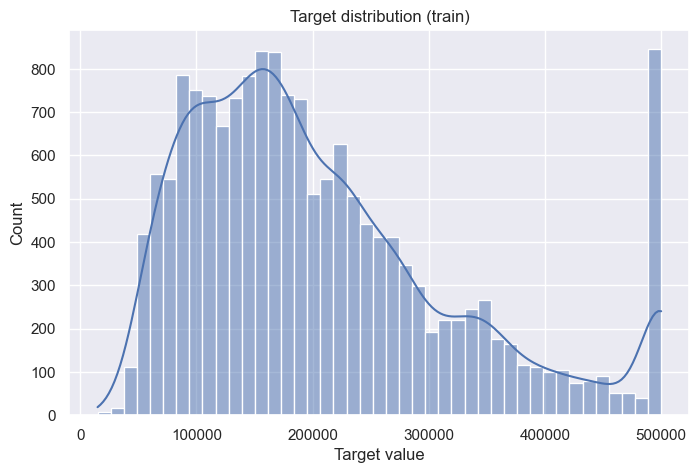

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(y_train, kde=True)
plt.title("Target distribution (train)")
plt.xlabel("Target value")
plt.show()

### Pipeline


In [29]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

### 2D PCA & KMeans
PCA Visualisering(två dimensioner) förklarade 54,7 % varians. K-means grupperar områden med liknande egenskaper och visar möjliga segment i datan. PCA och Kmeans visar vissa mönster och kluster i datan. PCA visar vissa klustermönster men ingen tydlig separation, vilket indikerar komplexa samband i data. KMeans grupperar data i tre segment, men kluster överlappar varandra och varierar i storlek.

Explained variance ratio: 35.5% and 19.2%
Total explained variance: 54.7%


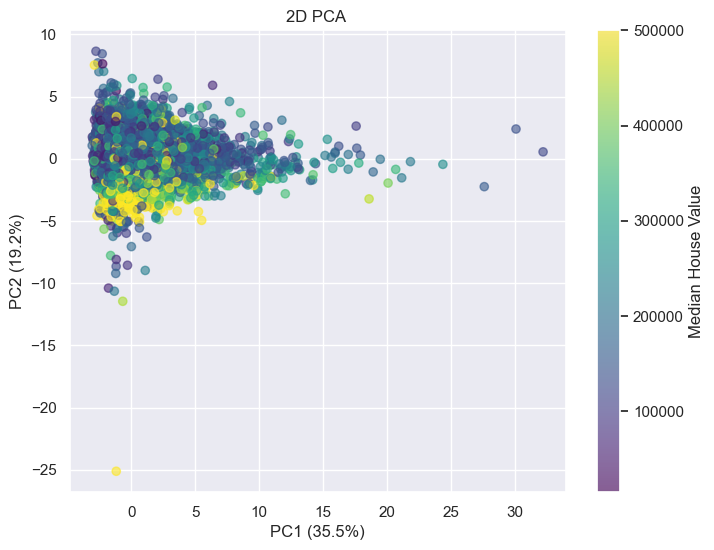

In [30]:
X_train_copy = X_train.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train_copy[numeric_features])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance ratio: {pca.explained_variance_ratio_[0]*100:.1f}% and {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total explained variance: {sum(pca.explained_variance_ratio_)*100:.1f}%")


plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='viridis', alpha=0.6)
plt.colorbar(label='Median House Value')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('2D PCA ')

plt.show()



In [31]:
pca_full = PCA()
pca_full.fit(X_scaled)
print(np.cumsum(pca_full.explained_variance_ratio_))

[0.355 0.547 0.714 0.806 0.883 0.945 0.978 0.99  0.995 0.999 1.   ]


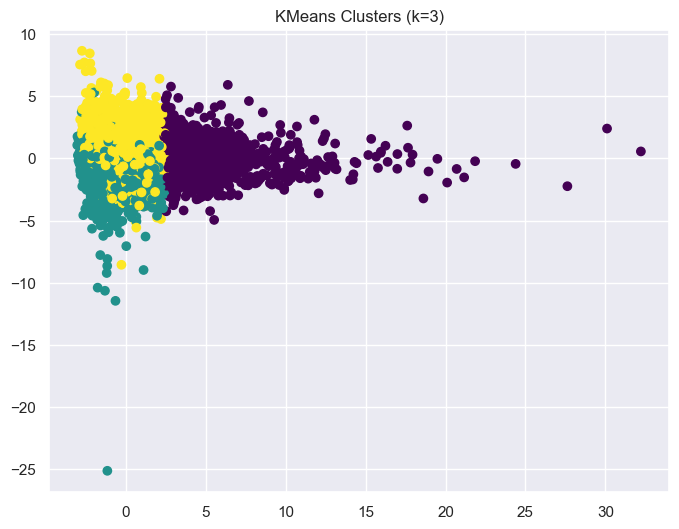

In [32]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.title("KMeans Clusters (k=3)")
plt.show()


### Modellering
1. Baseline → Linear Regression
2. Random Forest
3. Decision Tree

In [33]:
lin_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

models = {
    "Linear Regression": lin_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model,
    
}

### Jämför modellerna med cross-validation
Tre modeller (Linear Regression, Random Forestm och Decision Tree) tränades och jämfördes med 5-fold cross validation.
Random Forest uppnådde den lägsta RMSE.

Linear Regression:
  RMSE = 67848.83 (+/- 1562.85)
  MAE  = 48871.94 (+/- 789.95)

Decision Tree:
  RMSE = 71835.73 (+/- 1359.41)
  MAE  = 45830.70 (+/- 748.95)

Random Forest:
  RMSE = 50215.59 (+/- 658.89)
  MAE  = 32913.94 (+/- 283.00)

resultat från Cross validation
                           RMSE           MAE
Random Forest      50215.589142  32913.939374
Linear Regression  67848.831225  48871.935207
Decision Tree      71835.726925  45830.701788


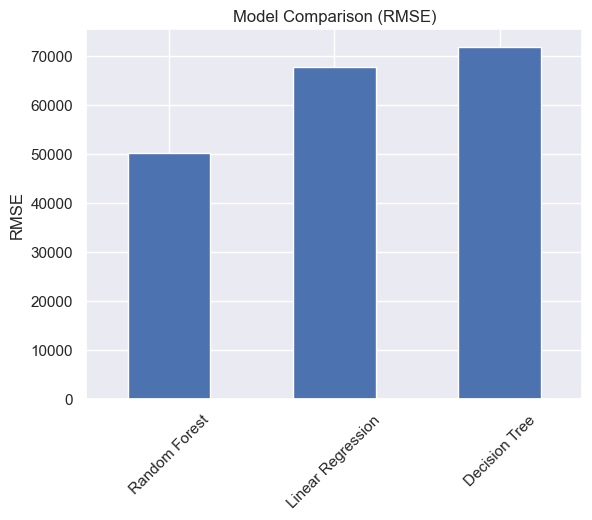

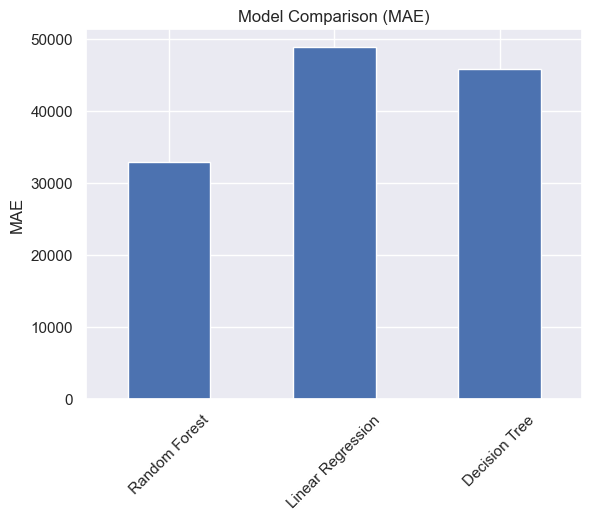

In [34]:
def evaluate_model(model):
    rmse_scores = np.sqrt(-cross_val_score(
        model, X_train, y_train,
        scoring="neg_mean_squared_error", cv=5
    ))
    
    mae_scores = -cross_val_score(
        model, X_train, y_train,
        scoring="neg_mean_absolute_error", cv=5
    )
    
    return rmse_scores, mae_scores


results = {}

for name, model in models.items():
    rmse_scores, mae_scores = evaluate_model(model)
    
    results[name] = {
        "RMSE": rmse_scores.mean(),
        "MAE": mae_scores.mean()
    }
    
    print(f"{name}:")
    print(f"  RMSE = {rmse_scores.mean():.2f} (+/- {rmse_scores.std():.2f})")
    print(f"  MAE  = {mae_scores.mean():.2f} (+/- {mae_scores.std():.2f})\n")


results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="RMSE")

print("resultat från Cross validation")
print(results_df)


# Plot RMSE
results_df["RMSE"].plot(kind="bar")
plt.ylabel("RMSE")
plt.title("Model Comparison (RMSE)")
plt.xticks(rotation=45)
plt.show()


# Plot MAE
results_df["MAE"].plot(kind="bar")
plt.ylabel("MAE")
plt.title("Model Comparison (MAE)")
plt.xticks(rotation=45)
plt.show()


### Välj och optimera(Hyperparameter Tuning) en modell

Root Mean Squared Error (RMSE) valdes som primärt utvärderingsmått.
Random Forest valdes som slutgiltig modell eftersom den uppnådde den lägsta RMSE under cross validation


Efter att ha valt att gå vidare med Random Forest har vi hyperparameter tunat. Med outliers i datan så fokuserar vi på RMSE (neg_root_mean_squared_error) som scoring metric.

Cross validation med 3-faldiga justeringar användes under hyperparameter tuning för att minska beräkningstiden för Random Forest-pipelinen. 

Vi har testat med följande hyperparametrar:
- n_estimators [50, 100] – antal träd i skogen, fler träd ger stabilare förutsägelser men tar längre tid att träna. Började med 50, 100. Sedan har jag försökt med höga värden som 200, 300 men det var så tidskrävande att jag har valt att tästa bara 50, 100.
- max_depth [10, 20, None] – hur djupa träden får växa, begränsar overfitting
- min_samples_split [2, 5] – minsta antal samples för att dela en nod, också för att begränsa overfitting



In [35]:
best_model_name = results_df.index[0]  
print('Vald modell för tuning:', best_model_name)

Vald modell för tuning: Random Forest


In [36]:
best_cv_model = models[best_model_name]

param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    best_cv_model,
    param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_


print("Best parameters:", grid_search.best_params_)

Best parameters: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 100}


## Slutlig utvärdering på testdata

In [37]:
def evaluate_test_model(y_true, y_pred, model_name="Model"):
    """
    Utvärdera regressionsmodellförutsägelser med hjälp av RMSE och MAE).
    
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    print(f"{model_name} Performance on Test Set:")
    print(f"  RMSE = {rmse:.2f}")
    print(f"  MAE  = {mae:.2f}\n")
    
    return {"Model": model_name, "RMSE": rmse, "MAE": mae}


In [38]:
test_predictions = best_model.predict(X_test)

test_results = evaluate_test_model(
    y_true=y_test,
    y_pred=test_predictions,
    model_name=f"Best model on test: {best_model_name}"
)

test_results_df = pd.DataFrame([test_results])


Best model on test: Random Forest Performance on Test Set:
  RMSE = 50390.88
  MAE  = 32388.17



In [39]:
summary = results_df.copy()
summary = summary.rename(columns={
    "RMSE": "RMSE (cv)",
    "MAE": "MAE (cv)"
})

summary["RMSE (test)"] = np.nan
summary["MAE (test)"] = np.nan


model_name = best_model_name  

summary.loc[model_name, "RMSE (test)"] = test_results["RMSE"]
summary.loc[model_name, "MAE (test)"] = test_results["MAE"]

summary


,RMSE (cv),MAE (cv),RMSE (test),MAE (test)
Random Forest,50215.589142,32913.939374,50390.876076,32388.168076
Linear Regression,67848.831225,48871.935207,NaN,NaN
Decision Tree,71835.726925,45830.701788,NaN,NaN


### Rekomendation
Resultaten från modelljämförelsen visar tydligt att Random Forest är den mest lämpliga modellen för att förutsäga medianbostadsvärden i Kalifornien. Modellen uppnådde lägst fel både i cross validation (RMSE ≈ 50 216) och på testdata (RMSE ≈ 50 391), vilket indikerar god generaliseringsförmåga och stabil prestanda.